# 국민은행_토스앱 리뷰 1년치 수집_저장_텍스트분석_mini_project
* 1. google play에서 국민은행 스타뱅킹앱, 토스앱의 사용자 리뷰를 1년치 수집
* 2. 수집한 리뷰를 mysql에 저장
* 3. 수집된 데이터로 긍정/부정 리뷰 비율 분석(막대 그래프 비교)
* 4. 워드클라우드 분석
* 5. LDA 토픽 모델링 분석(최적 k 탐색 포함)
* 6. word2vec 생성 후 T-sne 로 시각화
* 7. 분석 결과를 통해 얻을 수 있는 인사이트(문제점, 개선방안) 보고서 작성

# 분석 파트

In [6]:
# ! pip install sqlalchemy pymysql cryptography python-dotenv

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from konlpy.tag import Mecab
mecab = Mecab()
from sqlalchemy import create_engine
from dotenv import load_dotenv
load_dotenv("./.env2")

True

In [7]:
!pwd

/mnt/c/fintech4/06Machine_Learning_Deep_Learning


In [8]:
# !pip install cryptography

# DB에서 데이터 로드
* DB는 windows에 설치되어 있는 mysql이기 때문에 ubuntu에서 바로 접속이 안됨
  * 127.0.0.1(localhost)는 ubuntu의 localhost이기 때문
  * windows의 ip주소를 찾아서 host 주소에 넣어주어야함
* DB 접속 id, pw 문제
  * DB는 local에서는 root 계정 접속이 되지만 원격은 불가능함
  * ubuntu에서 windows에 설치된 db에 접속하는 것은 원격 접속이므로 원격 접속 전용 id, pw 생성이 필요
  * workbench에서 새로운 user id, pw 설정 후 권한 설정
  * 새로운 id, pw, host 번호를 이용해 DB 접속

In [9]:
dbname = "bank_app_reviews04"
dbid = os.getenv("user_id")
dbpw = os.getenv("user_pw")
host = os.getenv("user_host")
port = os.getenv("port")

In [10]:
host

'172.16.24.178'

In [11]:
engine = create_engine(f"mysql+pymysql://{dbid}:{dbpw}@{host}:{port}/{dbname}")
conn = engine.connect()

In [12]:
toss = pd.read_sql('viva.republica.toss', con=conn)
kb = pd.read_sql('com.kbstar.kbbank', con=conn)

In [14]:
toss

,리뷰일,평점,사용자리뷰,업체답변
0,2026-03-04,2,만보기복권긁기가 안되고 행운복권 2원받는 운세가 안됩니다.광고는 나오지만 2원받지가...,"안녕하세요. 고객 님, 토스팀입니다. 만족스러운 서비스를 제공하기 위해 노력하였으나..."
1,2026-03-04,1,어제 업데이트 이후로 제대로 되는게 없을 정도로 버그덩어리가 됬네요 빨리 수정업데이...,"안녕하세요. Sun Young 님, 토스팀입니다. 먼저 서비스 이용에 불편을 드려 ..."
2,2026-03-04,5,다 먹고 나오면 할인해준다고 알람뜨는거 킹받아서 어쩌면좋죠...? 사람 놀리는것도 ...,"안녕하세요. 뺑귄 님, 토스팀입니다. 먼저 서비스 이용에 불편을 드려 대단히 죄송합..."
3,2026-03-04,1,토스쇼핑 주소 변경 했는데 예전집으로 가있음,"안녕하세요. epic life 님, 토스팀입니다. 사용에 불편을 드린것 같아 죄송합..."
4,2026-03-04,3,아니 당장 급하게 송금할 일이 있어서 돈을 보내야하는데 뭐 인증하니까 안전한 금융거...,"안녕하세요. Electric 님, 토스팀입니다.남겨주신 내용만으로는 정확한 확인이 ..."
...,...,...,...,...
5815,2025-03-05,3,갑자기 토스 앱에서 다른 계좌로 송금이 되지 않습니다 왜 그런 거죠 뱅킹에서는 아무...,"안녕하세요. 윤성훈 님, 토스팀입니다. 남겨주신 내용만으로는 정확한 확인이 어려운 ..."
5816,2025-03-05,5,홈화면 커스텀 해서 보고싶은 계좌 세팅 다해놨는데 뭔 자주보는 계좌니 뭐니 맘대로 ...,"안녕하세요. Philip Park 님, 토스팀입니다. 서비스 변경으로 인해 불편을 ..."
5817,2025-03-05,5,가족들 한테 추천받아 사용중 쪼와요,NaN
5818,2025-03-05,1,토스증권 9시 10분 부터인거 왤케 짜치냥ㅋ 그리고 10번째 접속시 치킨 무료라더니...,"안녕하세요. 꼬미 님, 토스팀입니다. 남겨주신 내용만으로는 정확한 확인이 어려운 점..."


In [15]:
toss = toss.drop_duplicates()
toss

,리뷰일,평점,사용자리뷰,업체답변
0,2026-03-04,2,만보기복권긁기가 안되고 행운복권 2원받는 운세가 안됩니다.광고는 나오지만 2원받지가...,"안녕하세요. 고객 님, 토스팀입니다. 만족스러운 서비스를 제공하기 위해 노력하였으나..."
1,2026-03-04,1,어제 업데이트 이후로 제대로 되는게 없을 정도로 버그덩어리가 됬네요 빨리 수정업데이...,"안녕하세요. Sun Young 님, 토스팀입니다. 먼저 서비스 이용에 불편을 드려 ..."
2,2026-03-04,5,다 먹고 나오면 할인해준다고 알람뜨는거 킹받아서 어쩌면좋죠...? 사람 놀리는것도 ...,"안녕하세요. 뺑귄 님, 토스팀입니다. 먼저 서비스 이용에 불편을 드려 대단히 죄송합..."
3,2026-03-04,1,토스쇼핑 주소 변경 했는데 예전집으로 가있음,"안녕하세요. epic life 님, 토스팀입니다. 사용에 불편을 드린것 같아 죄송합..."
4,2026-03-04,3,아니 당장 급하게 송금할 일이 있어서 돈을 보내야하는데 뭐 인증하니까 안전한 금융거...,"안녕하세요. Electric 님, 토스팀입니다.남겨주신 내용만으로는 정확한 확인이 ..."
...,...,...,...,...
5815,2025-03-05,3,갑자기 토스 앱에서 다른 계좌로 송금이 되지 않습니다 왜 그런 거죠 뱅킹에서는 아무...,"안녕하세요. 윤성훈 님, 토스팀입니다. 남겨주신 내용만으로는 정확한 확인이 어려운 ..."
5816,2025-03-05,5,홈화면 커스텀 해서 보고싶은 계좌 세팅 다해놨는데 뭔 자주보는 계좌니 뭐니 맘대로 ...,"안녕하세요. Philip Park 님, 토스팀입니다. 서비스 변경으로 인해 불편을 ..."
5817,2025-03-05,5,가족들 한테 추천받아 사용중 쪼와요,NaN
5818,2025-03-05,1,토스증권 9시 10분 부터인거 왤케 짜치냥ㅋ 그리고 10번째 접속시 치킨 무료라더니...,"안녕하세요. 꼬미 님, 토스팀입니다. 남겨주신 내용만으로는 정확한 확인이 어려운 점..."


In [16]:
kb = kb.drop_duplicates()
kb

,리뷰일,평점,사용자리뷰,업체답변
0,2026-03-04,5,"제 첫알바때부터 쭈욱 함께해온 국민은행, 그리고 스타뱅킹. 어플리케이션 사용이 편하...","고객님, 안녕하세요! KB스타뱅킹을 꾸준히 이용해 주셔서 진심으로 감사합니다. KB..."
1,2026-03-04,5,아주 편리하다,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사합니다. 앞으로도 고객...
2,2026-03-04,5,사용하기 편하네요,고객님 안녕하세요! KB스타뱅킹을 이용해 주시고 바쁘신 와중에 칭찬글까지 남겨주시어...
3,2026-03-04,5,굿,"안녕하세요, 고객님. KB스타뱅킹을 꾸준히 이용해주시고 소중한 시간을 내어 칭찬 글..."
4,2026-03-04,5,편리합니다.연동도 잘됨,"안녕하세요, 고객님. KB스타뱅킹을 꾸준히 이용해주시는 고객님께 진심으로 감사의 말..."
...,...,...,...,...
4175,2025-03-05,5,굿,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...
4176,2025-03-05,5,빠른 실행 좋아요,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...
4177,2025-03-05,5,편해요,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...
4178,2025-03-05,5,굿경험^^,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...


In [9]:
toss.info()

<class 'pandas.DataFrame'>
Index: 5795 entries, 0 to 5819
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   리뷰일     5795 non-null   datetime64[us]
 1   평점      5795 non-null   str           
 2   사용자리뷰   5795 non-null   str           
 3   업체답변    4969 non-null   str           
dtypes: datetime64[us](1), str(3)
memory usage: 226.4 KB


# 긍정 부정 비율 분석 및 리뷰 점수 트랜드 분석

In [17]:
toss['평점'] = toss['평점'].astype(int) 

<Axes: xlabel='리뷰일'>

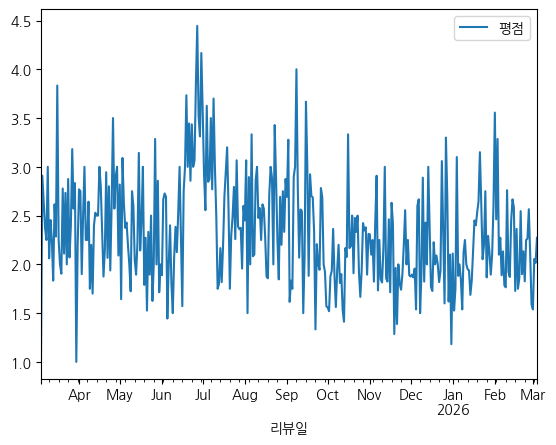

In [11]:
toss[['리뷰일', '평점']].groupby("리뷰일").mean().reset_index().sort_values(by="리뷰일").plot(x='리뷰일', y='평점')

In [12]:
toss['평점'].value_counts()

평점
1    3038
5    1123
3     681
2     505
4     448
Name: count, dtype: int64

In [13]:
toss['긍정'] = toss['평점'].apply(lambda x: 1 if x > 3 else 0)
toss

,리뷰일,평점,사용자리뷰,업체답변,긍정
0,2026-03-04,2,만보기복권긁기가 안되고 행운복권 2원받는 운세가 안됩니다.광고는 나오지만 2원받지가...,"안녕하세요. 고객 님, 토스팀입니다. 만족스러운 서비스를 제공하기 위해 노력하였으나...",0
1,2026-03-04,1,어제 업데이트 이후로 제대로 되는게 없을 정도로 버그덩어리가 됬네요 빨리 수정업데이...,"안녕하세요. Sun Young 님, 토스팀입니다. 먼저 서비스 이용에 불편을 드려 ...",0
2,2026-03-04,5,다 먹고 나오면 할인해준다고 알람뜨는거 킹받아서 어쩌면좋죠...? 사람 놀리는것도 ...,"안녕하세요. 뺑귄 님, 토스팀입니다. 먼저 서비스 이용에 불편을 드려 대단히 죄송합...",1
3,2026-03-04,1,토스쇼핑 주소 변경 했는데 예전집으로 가있음,"안녕하세요. epic life 님, 토스팀입니다. 사용에 불편을 드린것 같아 죄송합...",0
4,2026-03-04,3,아니 당장 급하게 송금할 일이 있어서 돈을 보내야하는데 뭐 인증하니까 안전한 금융거...,"안녕하세요. Electric 님, 토스팀입니다.남겨주신 내용만으로는 정확한 확인이 ...",0
...,...,...,...,...,...
5815,2025-03-05,3,갑자기 토스 앱에서 다른 계좌로 송금이 되지 않습니다 왜 그런 거죠 뱅킹에서는 아무...,"안녕하세요. 윤성훈 님, 토스팀입니다. 남겨주신 내용만으로는 정확한 확인이 어려운 ...",0
5816,2025-03-05,5,홈화면 커스텀 해서 보고싶은 계좌 세팅 다해놨는데 뭔 자주보는 계좌니 뭐니 맘대로 ...,"안녕하세요. Philip Park 님, 토스팀입니다. 서비스 변경으로 인해 불편을 ...",1
5817,2025-03-05,5,가족들 한테 추천받아 사용중 쪼와요,NaN,1
5818,2025-03-05,1,토스증권 9시 10분 부터인거 왤케 짜치냥ㅋ 그리고 10번째 접속시 치킨 무료라더니...,"안녕하세요. 꼬미 님, 토스팀입니다. 남겨주신 내용만으로는 정확한 확인이 어려운 점...",0


In [14]:
toss['긍정'].value_counts()

긍정
0    4224
1    1571
Name: count, dtype: int64

<Axes: xlabel='긍정'>

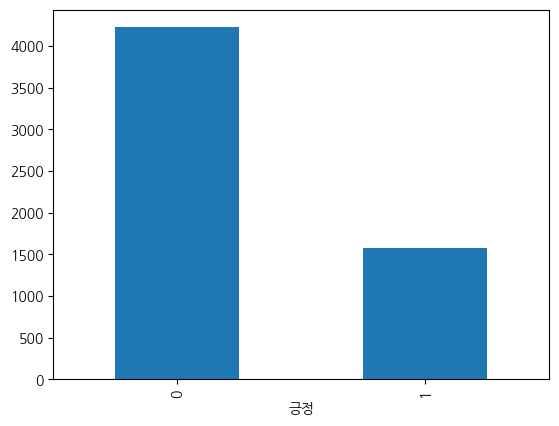

In [15]:
toss['긍정'].value_counts().plot(kind='bar')

In [16]:
kb['평점'] = kb['평점'].astype(int) 

<Axes: xlabel='리뷰일'>

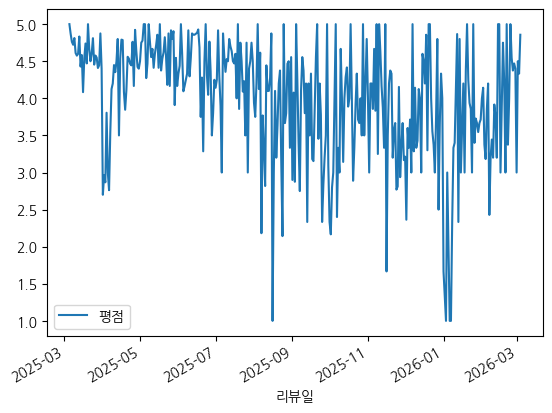

In [17]:
kb[['리뷰일', '평점']].groupby("리뷰일").mean().reset_index().sort_values(by="리뷰일").plot(x='리뷰일', y='평점')

In [18]:
kb['긍정'] = kb['평점'].apply(lambda x: 1 if x > 3 else 0)
kb

,리뷰일,평점,사용자리뷰,업체답변,긍정
0,2026-03-04,5,"제 첫알바때부터 쭈욱 함께해온 국민은행, 그리고 스타뱅킹. 어플리케이션 사용이 편하...","고객님, 안녕하세요! KB스타뱅킹을 꾸준히 이용해 주셔서 진심으로 감사합니다. KB...",1
1,2026-03-04,5,아주 편리하다,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사합니다. 앞으로도 고객...,1
2,2026-03-04,5,사용하기 편하네요,고객님 안녕하세요! KB스타뱅킹을 이용해 주시고 바쁘신 와중에 칭찬글까지 남겨주시어...,1
3,2026-03-04,5,굿,"안녕하세요, 고객님. KB스타뱅킹을 꾸준히 이용해주시고 소중한 시간을 내어 칭찬 글...",1
4,2026-03-04,5,편리합니다.연동도 잘됨,"안녕하세요, 고객님. KB스타뱅킹을 꾸준히 이용해주시는 고객님께 진심으로 감사의 말...",1
...,...,...,...,...,...
4175,2025-03-05,5,굿,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,1
4176,2025-03-05,5,빠른 실행 좋아요,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,1
4177,2025-03-05,5,편해요,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,1
4178,2025-03-05,5,굿경험^^,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,1


<Axes: xlabel='긍정'>

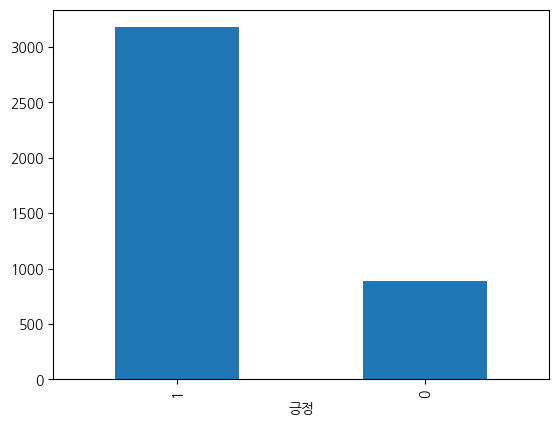

In [19]:
kb['긍정'].value_counts().plot(kind='bar')

# 워드클라우드 분석

In [20]:
from wordcloud import WordCloud

In [21]:
def text_clean(text):
    temp = re.sub(r"[^가-힣a-zA-Z0-9]", " ", text)
    temp = temp.replace("  ", " ").replace("  ", " ").strip()
    return temp

In [22]:
def mecab_tokenizer(text):
    return [w for w in mecab.morphs(str(text)) if len(w) > 1]

In [23]:
toss.loc[toss['긍정'] == 1, '사용자리뷰']

2       다 먹고 나오면 할인해준다고 알람뜨는거 킹받아서 어쩌면좋죠...? 사람 놀리는것도 ...
6       '자산 변화'에서 총자산으로 설정한 금액으로 "그래프에서도 동일하게 월변화를 볼수있...
13            광고 보고 포인트 받아져야 되는데 다시 광고가 재생되네요. 오류 수정바랍니다.
16      다 좋은데 토스 행운복권 그거 매일 하는데 오늘부터 첫단계만 되고 나머지 단계로 안...
24      일주일 방문 미션 버그만 좀 해결해라 제발 존재하지 않는 상품은 왜 있는거야 사실 ...
                              ...                        
5809                             환전수수료 평생 무료가 아직도 유효 한가요?
5811    편하게 잘 사용하고 포인트도 많이 적립할수있어서 좋음. 단, 방문미션은 정답이 맞는...
5812                              시간가는줄 모르게 즐거운 여행이였습니다^^
5816    홈화면 커스텀 해서 보고싶은 계좌 세팅 다해놨는데 뭔 자주보는 계좌니 뭐니 맘대로 ...
5817                                  가족들 한테 추천받아 사용중 쪼와요
Name: 사용자리뷰, Length: 1571, dtype: str

In [24]:
# 은행별 긍정 부정 리뷰 모음
toss_pos = toss.loc[toss['긍정'] == 1, '사용자리뷰']
toss_neg = toss.loc[toss['긍정'] == 0, '사용자리뷰']
kb_pos = kb.loc[kb['긍정'] == 1, '사용자리뷰']
kb_neg = kb.loc[kb['긍정'] == 0, '사용자리뷰']

In [25]:
reviews = [toss_pos, toss_neg, kb_pos, kb_neg]
kinds = ["토스 긍정", "토스 부정", "국민 긍정", "국민 부정"]

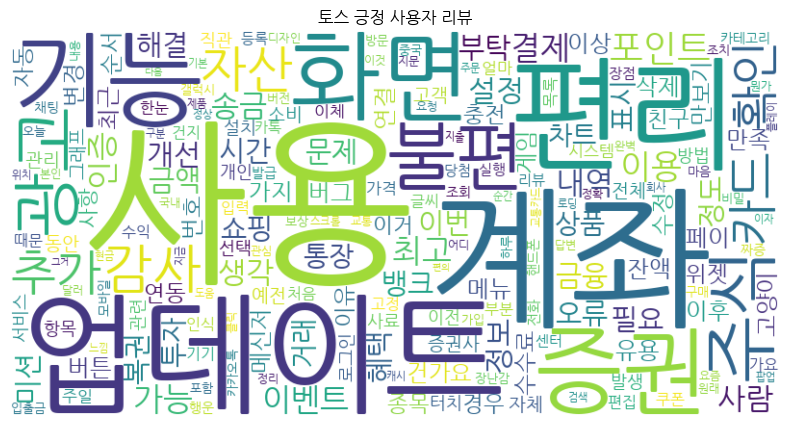

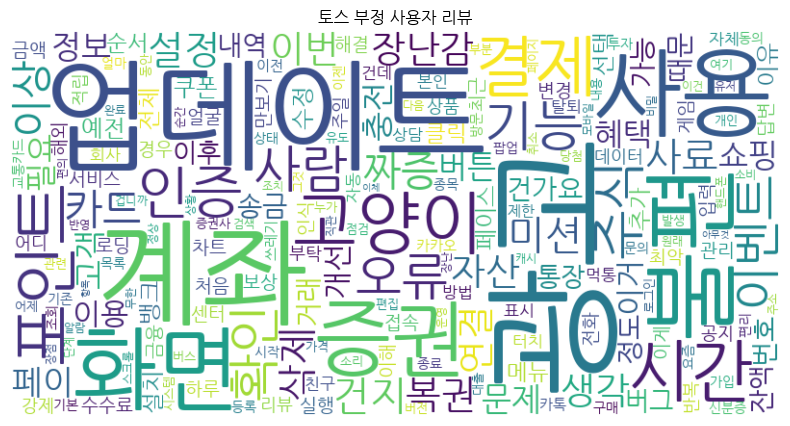

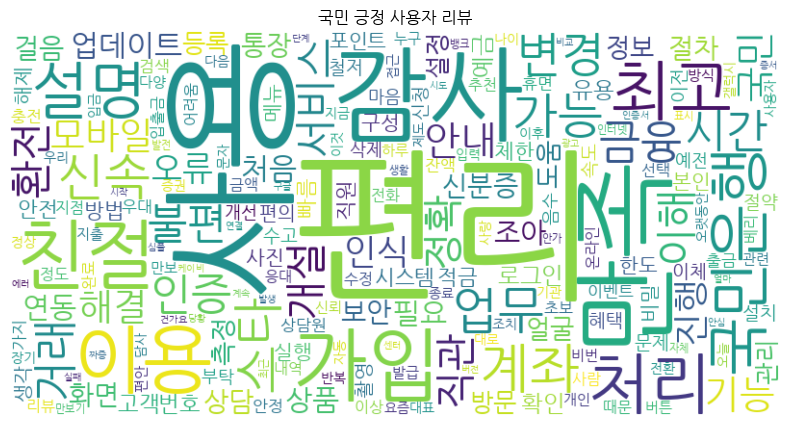

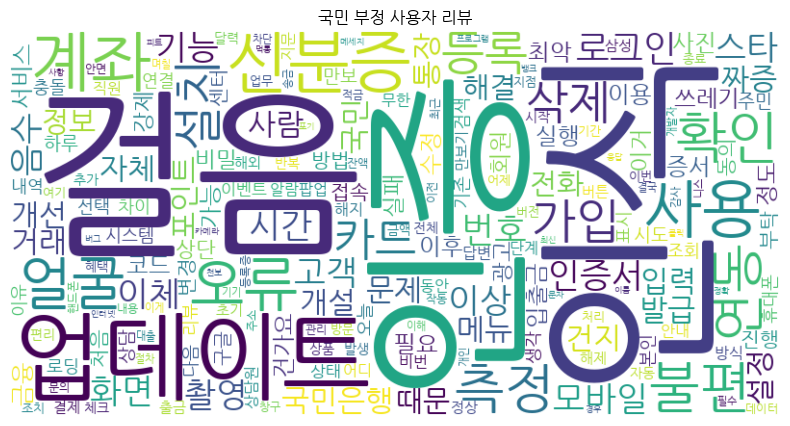

In [26]:
for review, kind in zip(reviews, kinds):
    text_data = review.astype(str).tolist()
    full_text = " ".join(text_data)

    stopwords = set(['은행', '어플', '뱅킹', '앱', '하나', 'toss', '토스'])

    nouns = mecab.nouns(full_text)
    filtered = [word for word in nouns if len(word) > 1 and word not in stopwords]

    from collections import Counter
    word_freq = Counter(filtered)

    wc = WordCloud(
            font_path="NanumGothic.ttf",
            background_color="white",
            width=800,
            height=400
            ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"{kind} 사용자 리뷰")
#     plt.savefig(f"./data/{hana_pos['은행명'].unique()[0]} {hana_pos['긍정'].unique()[0]} 사용자 리뷰.png",
#                 dpi=300, bbox_inches='tight')
    plt.show()


# LDA 기반 토픽 모델링

In [30]:
# =========================
# ✅ MeCab tokenizer 통일 버전 (전체 코드)
# - best_k(최적 토픽 수 탐색)과 실제 LDA 학습/출력까지
#   모두 동일한 tokenizer/벡터화 기준으로 맞춘 코드
# =========================
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel

In [31]:
# -------------------------
# 1) 토크나이저 (요청하신 방식)
# -------------------------
def mecab_tokenizer(text):
    return [w for w in mecab.morphs(str(text)) if len(w) > 1]


# -------------------------
# 2) 최적 토픽 수 탐색 (중복 토큰화 제거 + 필터 일관성)
#    - 반환: (best_k, filtered_texts, tokenized_texts)
#      -> 바깥에서 같은 문서셋으로 LDA 학습 가능
# -------------------------
def find_optimal_topics(texts, start=2, end=20, min_df=5, max_df=0.9, topn=10, random_state=42):
    # 1) 토큰화 1회 + 길이필터 (원문/토큰 함께 보존)
    pairs = [(t, mecab_tokenizer(t)) for t in texts]
    pairs = [(t, tok) for (t, tok) in pairs if len(tok) >= 2]

    filtered_texts = [t for (t, tok) in pairs]        # List[str]
    tokenized_texts = [tok for (t, tok) in pairs]     # List[List[str]]

    if len(tokenized_texts) < 5:
        return start, filtered_texts, tokenized_texts

    # 2) 토픽 상한 자동 축소
    max_k = min(end, max(start, len(tokenized_texts) // 2))
    if max_k < start:
        return start, filtered_texts, tokenized_texts

    # 3) coherence 계산용 dictionary
    dictionary = corpora.Dictionary(tokenized_texts)

    print("단어 개수:", len(dictionary))
    print("샘플 단어:", list(dictionary.token2id.keys())[:20])

    # 4) DTM 생성 (입력은 원문 텍스트, tokenizer는 mecab)
    vectorizer = CountVectorizer(
        tokenizer=mecab_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        min_df=min_df,
        max_df=max_df
    )

    try:
        doc_term_matrix = vectorizer.fit_transform(filtered_texts)
    except ValueError:
        print(" (find_optimal_topics) 벡터화 오류 -> 기본 토픽 수 반환.")
        return start, filtered_texts, tokenized_texts

    if doc_term_matrix.shape[1] == 0:
        print(" (find_optimal_topics) min_df/max_df로 단어 전부 제거 -> 기본 토픽 수 반환.")
        return start, filtered_texts, tokenized_texts

    feature_names = vectorizer.get_feature_names_out()

    best_score = -1
    best_n = start

    for n_topics in range(start, max_k + 1):
        lda_model = LatentDirichletAllocation(
            n_components=n_topics,
            random_state=random_state,
            learning_method="batch"
        )
        lda_model.fit(doc_term_matrix)

        topics = [
            [feature_names[i] for i in topic.argsort()[:-topn-1:-1]]
            for topic in lda_model.components_
        ]

        cm = CoherenceModel(
            topics=topics,
            texts=tokenized_texts,
            dictionary=dictionary,
            coherence="c_v"
        )
        score = cm.get_coherence()

        print(f"  → 토픽 수: {n_topics}, Coherence Score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_n = n_topics

    print(f"  ➡️ 최적 토픽 수: {best_n} (Score: {best_score:.4f})")
    return best_n, filtered_texts, tokenized_texts

In [33]:
# -------------------------
# 3) 실제 토픽 모델링 실행 (pos_neg_dict 루프)
#    - best_k 계산에 사용한 "filtered_texts"로 그대로 LDA 학습 (일관성)
#    - topic_words_map 저장 (나중에 Word2Vec/t-SNE만 따로 가능)
# -------------------------
print("--- 토픽 모델링 시작 ---")

VEC_MIN_DF = 10
VEC_MAX_DF = 0.9

TOPN_WORDS_PRINT = 10
TOPN_COHERENCE = 10

START_K = 2
END_K = 20

topic_words_map = {}  # (bank_eng, senti) -> set(topic words)

for review, kind in zip(reviews, kinds):
    review = review.apply(text_clean)
    series = review.dropna()

    if len(series) < 20:
        print(f"{kind} 리뷰 수 부족 ({len(series)}개) - 스킵")
        continue

    texts = series.tolist()

    # 1) 최적 토픽 수 + 필터된 문서셋을 함께 받기
    best_k, filtered_texts, tokenized_texts = find_optimal_topics(
        texts=texts,
        start=START_K,
        end=END_K,
        min_df=VEC_MIN_DF,
        max_df=VEC_MAX_DF,
        topn=TOPN_COHERENCE,
        random_state=42
    )

    # 필터 후 문서가 너무 적으면 스킵 (토큰 기준이 더 중요)
    if len(tokenized_texts) < 20:
        print(f"{kind}) 유효 토큰 문서 부족 ({len(tokenized_texts)}개) - 스킵")
        continue

    # 2) 실제 학습도 "filtered_texts"로 통일 (중요!)
    vectorizer = CountVectorizer(
        tokenizer=mecab_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        min_df=VEC_MIN_DF,
        max_df=VEC_MAX_DF
    )

    try:
        review_vec = vectorizer.fit_transform(filtered_texts)
    except ValueError:
        print(f"{kind}) 벡터화 오류 - 스킵")
        continue

    if review_vec.shape[1] == 0:
        print(f"{kind}) min_df={VEC_MIN_DF} 조건 만족 단어 없음 - 스킵")
        continue

    lda = LatentDirichletAllocation(
        n_components=best_k,
        random_state=42,
        learning_method="batch"
    )
    lda.fit(review_vec)

    words = vectorizer.get_feature_names_out()

    # 토픽 단어 출력 + 저장
    all_topic_words = set()

    print(f"\n{kind} 토픽 {best_k}개 - 상위 단어")
    print("=" * 60)
    for i, topic in enumerate(lda.components_):
        top_idx = topic.argsort()[-TOPN_WORDS_PRINT:][::-1]
        top_words = [words[idx] for idx in top_idx]
        print(f"토픽 #{i}: {top_words}\n")
        all_topic_words.update(top_words)

    a[(kind)] = all_topic_words

print("--- 토픽 모델링 종료 ---")

--- 토픽 모델링 시작 ---
단어 개수: 3338
샘플 단어: ['같이', '귀신', '나오', '놀리', '던가', '들어오', '바로', '사람', '아니', '아서', '어쩌면', '준다고', '할인', '그래프', '금액', '늘릴', '다면', '동일', '메뉴', '변화']
  → 토픽 수: 2, Coherence Score: 0.5274
  → 토픽 수: 3, Coherence Score: 0.5497
  → 토픽 수: 4, Coherence Score: 0.5529
  → 토픽 수: 5, Coherence Score: 0.5592
  → 토픽 수: 6, Coherence Score: 0.5587
  → 토픽 수: 7, Coherence Score: 0.5668
  → 토픽 수: 8, Coherence Score: 0.5395
  → 토픽 수: 9, Coherence Score: 0.5420
  → 토픽 수: 10, Coherence Score: 0.5129
  → 토픽 수: 11, Coherence Score: 0.5753
  → 토픽 수: 12, Coherence Score: 0.5213
  → 토픽 수: 13, Coherence Score: 0.5642
  → 토픽 수: 14, Coherence Score: 0.5635
  → 토픽 수: 15, Coherence Score: 0.5628
  → 토픽 수: 16, Coherence Score: 0.5391
  → 토픽 수: 17, Coherence Score: 0.5675
  → 토픽 수: 18, Coherence Score: 0.5525
  → 토픽 수: 19, Coherence Score: 0.5417
  → 토픽 수: 20, Coherence Score: 0.5155
  ➡️ 최적 토픽 수: 11 (Score: 0.5753)

토스 긍정 토픽 11개 - 상위 단어
토픽 #0: ['토스', '만들', '세요', '습니다', '나요', '메신저', '결제', '입니다', '페이', '어요'

In [40]:
topic_words_map.items()

dict_items([('토스 긍정', {'증권', '화면', '순서', '포인트', '결제', '으면', '제발', '가능', '업데이트', '보이', '갑자기', '감사', '다른', '계좌', '해서', '아주', '편하', '만들', '습니다', '은행', '으로', '확인', 'UI', '이용', '해야', '광고', '아니', '어서', '게임', '상품', '토스', '세요', '합니다', '자주', '에서', '사용', '다시', '문제', '은데', '어요', '불편', '카드', '아요', '나요', '네요', '고양이', '기능', '최고', '차트', '자산', '입니다', '는데', '메신저', '미션', '추가', '주식', '편리', '해요', '뱅크', '페이', '충전', '너무'}), ('토스 부정', {'증권', '화면', '시간', '포인트', '결제', '나오', '보이', '업데이트', '고객', '다른', '계좌', '오류', '접속', '복권', '사료', '라는', '이벤트', '습니다', '으로', '확인', '라고', '만보기', '광고', '아니', '없애', '토스', '까지', '세요', '사용', '합니다', '에서', '연결', '다시', '알림', '갈수록', '인증', '삭제', '어요', '불편', '카드', '번호', '키우', '네요', '고양이', '계속', '차트', '는데', '장난감', '페이스', '주식', '부터', '그만', '늘리', '페이', '충전', '너무'}), ('국민 긍정', {'시간', '편함', '뱅킹', '환전', '상담', '가입', '처음', '가능', '만족', '감사', 'KB', '거래', '계좌', '다른', '해서', '아주', '편하', '항상', '습니다', '간단', '으로', '은행', '이용', '스타', '신속', '업무', '어서', '개설', '빠르', '상품', '친절', '세요', '직관', '사용', '국민은행', '에서', '합니다

['만보기복권긁기가 안되고 행운복권 2원받는 운세가 안됩니다 광고는 나오지만 2원받지가 안됩니다',
 '어제 업데이트 이후로 제대로 되는게 없을 정도로 버그덩어리가 됬네요 빨리 수정업데이트 해주세요',
 '다 먹고 나오면 할인해준다고 알람뜨는거 킹받아서 어쩌면좋죠  사람 놀리는것도 아니고 가게 들어오면 바로바로 뜨던가 귀신같이 나오면 뜸',
 '토스쇼핑 주소 변경 했는데 예전집으로 가있음',
 '아니 당장 급하게 송금할 일이 있어서 돈을 보내야하는데 뭐 인증하니까 안전한 금융거래를 위해 3일뒤부터 송금가능하다고 하면 저같은 사람들은 대체 뭘 어쩌라는 겁니까 아무리 3일뒤에는 송금에 제한이 없다 하더라도 당장 급한 상황에서 어떻게 할 도리가 없는데 인증할 때도 아무런 보고가 없어가지고 그냥 단순한 인증인줄 알았는데 3일에 제한이 걸리는 건 줄 누가 압니까 담부터 이런 인증 절차 진행할때 미리 사전보고 같은 걸 해주셨으면 좋겠습니다',
 '도드람농협 수협 계좌 안불러와지는데 개선 부탁좀요',
 '자산 변화 에서 총자산으로 설정한 금액으로 그래프에서도 동일하게 월변화를 볼수있게 해 주세요 설정한 자산으로는 힘들다면 토스증권 에 자산의 월간변화를 볼수 있는 메뉴를 추가 해 주세요 사용자를 늘릴 수 있는 편의사항입니다',
 '앱이 너무 무거워서 버그랑 렉이 너무 심함 이걸 몇개월 방치하는게 어이가 없음 쇼핑이니 광고니 계속 쓸데없는것만 늘어나고 ui가 편해서 토스 썼는데 렉이 너무 심해져서 오히려 불편해짐',
 '처음 설치하면 홈화면까지 가는데 쓸데없는 절차가 왜 이렇거 많은지 짜증나서 삭제했어요',
 '지금 앱 업데이트 후에 행운 복권 포인트 받기가 안됩니다 광고를 봤는데도 그러네요',
 '서버 관리 안하냐 진짜 주식 사는데 체결이 3분 뒤에 계속 쳐 되서 손해는 손해대로 보고 이익은 볼건 못보고 진짜 짜증나네',
 '업데이후 혜택부분에서 오류가 생기는거같아요',
 '카메라 사용 불가능한 환경인데 인증마다 모바일 신분증은 사용도안되고 무조건 신분증 촬영만 하라는건 좀

In [34]:
from gensim.models import CoherenceModel, Word2Vec
from sklearn.manifold import TSNE

✅ Word2Vec 학습 완료 | 전체 리뷰: 9864 | 유효 토큰 문서: 8524

(토스 긍정) 토픽단어 62개 | W2V 포함 62개
   ▶ t-SNE perplexity = 15


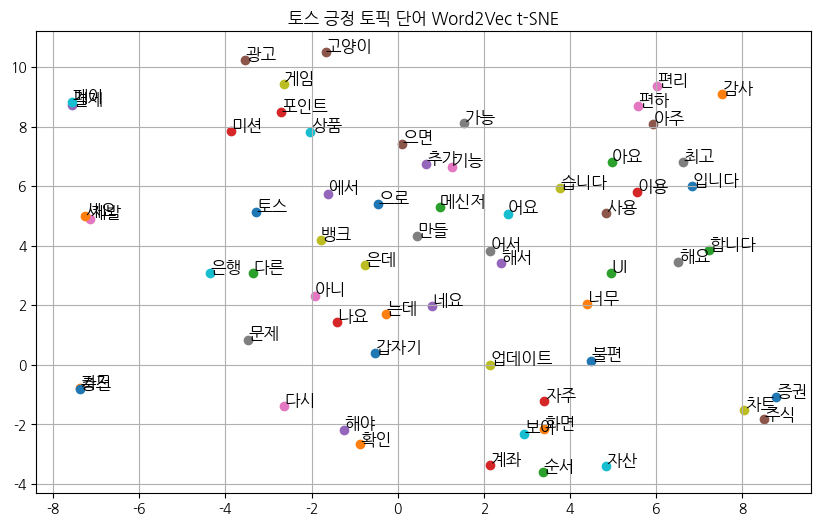


(토스 부정) 토픽단어 56개 | W2V 포함 56개
   ▶ t-SNE perplexity = 15


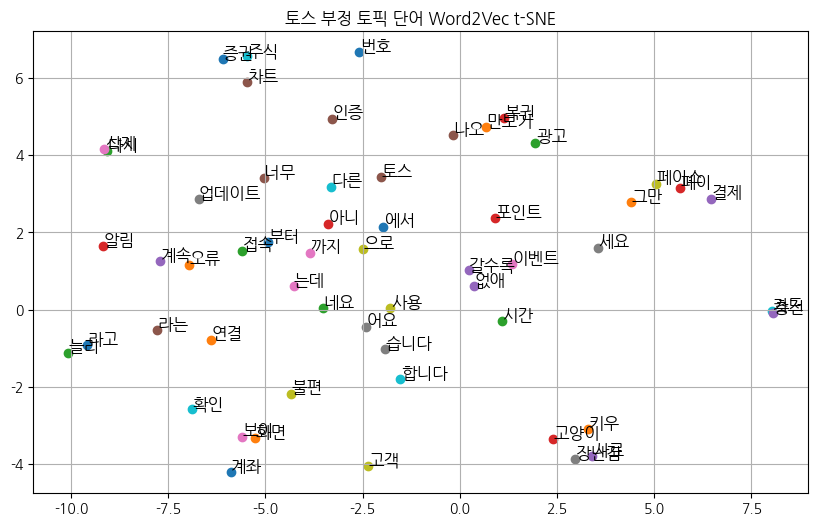


(국민 긍정) 토픽단어 67개 | W2V 포함 67개
   ▶ t-SNE perplexity = 15


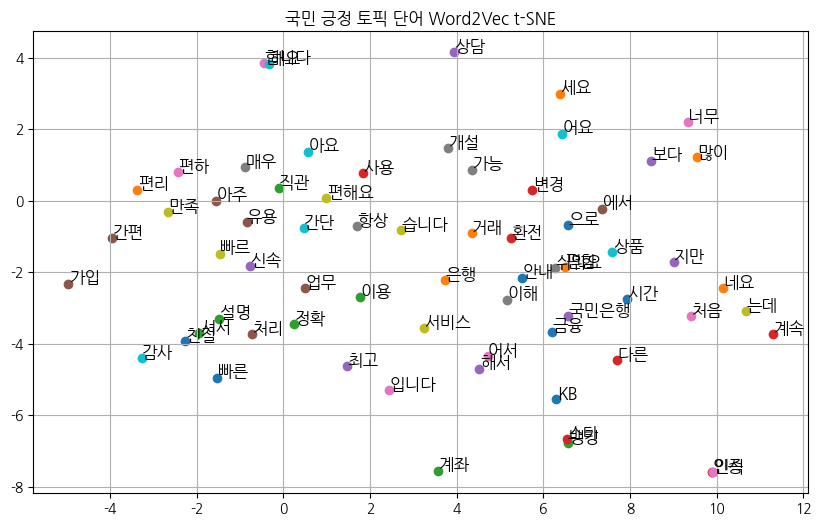


(국민 부정) 토픽단어 40개 | W2V 포함 40개
   ▶ t-SNE perplexity = 13


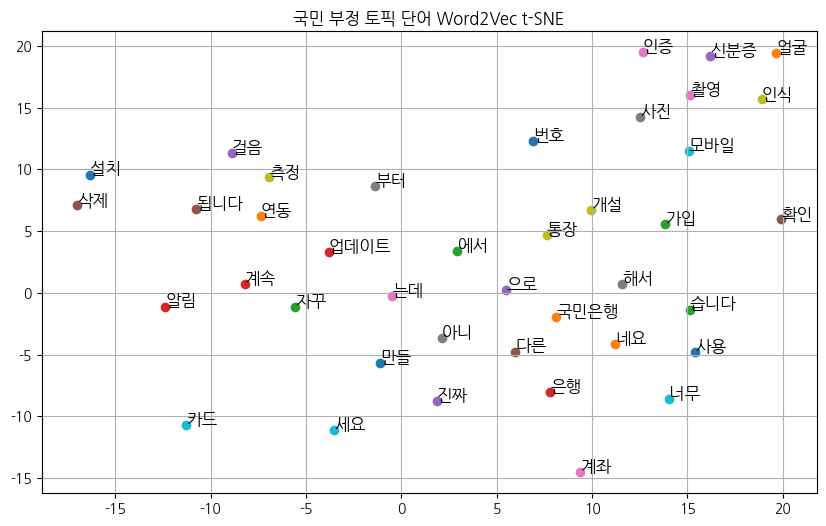

In [41]:
# =========================
# ✅ Word2Vec + t-SNE 시각화만 (토픽 모델링 재실행 없음)
# 필요 전제: topic_words_map 이 존재해야 함
#   - topic_words_map[(bank_eng, senti)] = set(토픽 단어들)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from gensim.models import Word2Vec

# -------------------------
# 1) MeCab tokenizer (동일 기준)
# -------------------------
def mecab_tokenizer(text):
    return [w for w in mecab.morphs(str(text)) if len(w) > 1]

def tokenize_docs(texts):
    tokenized = []
    for t in texts:
        toks = mecab_tokenizer(t)
        if len(toks) >= 2:
            tokenized.append(toks)
    return tokenized


# -------------------------
# 2) Word2Vec 한 번만 학습 (train_df 있을 때)
# -------------------------
W2V_VECTOR_SIZE = 100
W2V_WINDOW = 5
W2V_MIN_COUNT = 2
W2V_WORKERS = 4
W2V_SG = 1
W2V_SEED = 42

w2v_model = None


all_reviews = toss['사용자리뷰'].dropna().apply(text_clean).tolist() + kb['사용자리뷰'].dropna().apply(text_clean).tolist()
all_tokenized = tokenize_docs(all_reviews)

if len(all_tokenized) >= 5:
    w2v_model = Word2Vec(
        sentences=all_tokenized,
        vector_size=W2V_VECTOR_SIZE,
        window=W2V_WINDOW,
        min_count=W2V_MIN_COUNT,
        workers=W2V_WORKERS,
        sg=W2V_SG,
        seed=W2V_SEED
    )
    print(f"✅ Word2Vec 학습 완료 | 전체 리뷰: {len(all_reviews)} | 유효 토큰 문서: {len(all_tokenized)}")
else:
    print("⚠ Word2Vec 학습용 유효 토큰 문서가 너무 적어 학습을 건너뜁니다.")



# -------------------------
# 3) t-SNE 시각화 (topic_words_map 기반)
# -------------------------
if w2v_model is None:
    print("⚠ w2v_model이 없어 t-SNE 시각화를 할 수 없습니다.")
elif 'topic_words_map' not in globals() or len(topic_words_map) == 0:
    print("⚠ topic_words_map이 없습니다. (토픽 모델링 단계에서 토픽 단어 set 저장 필요)")
else:
    for bank_senti, all_topic_words in topic_words_map.items():
        valid_words = [w for w in all_topic_words if w in w2v_model.wv]

        print(f"\n({bank_senti}) 토픽단어 {len(all_topic_words)}개 | W2V 포함 {len(valid_words)}개")

        if len(valid_words) < 3:
            print("   ⚠ Word2Vec에 있는 단어가 3개 미만이라 스킵")
            continue

        vectors = np.array([w2v_model.wv[w] for w in valid_words])

        # perplexity 자동 조절
        tsne_perplexity = min(15, max(5, (len(valid_words) - 1) // 3))
        tsne_perplexity = min(tsne_perplexity, len(valid_words) - 1)
        if tsne_perplexity < 2:
            tsne_perplexity = 2
        print(f"   ▶ t-SNE perplexity = {tsne_perplexity}")

        tsne = TSNE(
            n_components=2,
            random_state=0,
            perplexity=tsne_perplexity,
            init="pca",
            learning_rate="auto"
        )
        reduced_vecs = tsne.fit_transform(vectors)

        plt.figure(figsize=(10, 6))
        for i, word in enumerate(valid_words):
            x, y = reduced_vecs[i]
            plt.scatter(x, y)
            plt.text(x + 0.01, y + 0.01, word, fontsize=12)

        plt.title(f"{bank_senti} 토픽 단어 Word2Vec t-SNE")
        plt.grid(True)
        plt.show()